In [1]:
import pandas as pd, numpy as np, os, json, joblib
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report)

df = pd.read_csv("../data/processed/features_dataset.csv")

num_cols = ["years_experience", "certifications_count", "profile_completeness_pct",
            "log_endorsements", "skill_count", "education_ord", "update_ord",
            "connections_ord", "in_demand_skill_flag_bin", "open_to_work_bin",
            "uses_generative_ai_tools_bin"]
cat_cols = ["work_mode"]

X, y = df[num_cols + cat_cols], df["high_employability"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

pre = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(drop="first"), cat_cols)])

model = Pipeline([("pre", pre), ("clf", LogisticRegression(max_iter=1000))])
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('pre', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](12,)","['years_experience','certifications_count','profile_completeness_pct',..., 'open_to_work_bin','uses_generative_ai_tools_bin','work_mode']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,12
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'d

{'accuracy': 0.695, 'precision': 0.6967, 'recall': 0.6933, 'f1': 0.695, 'roc_auc': 0.7646, 'cv_accuracy_mean': np.float64(0.6977), 'cv_accuracy_std': np.float64(0.0068)}
              precision    recall  f1-score   support

         Low       0.69      0.70      0.69      1197
        High       0.70      0.69      0.69      1203

    accuracy                           0.69      2400
   macro avg       0.70      0.70      0.69      2400
weighted avg       0.70      0.69      0.69      2400



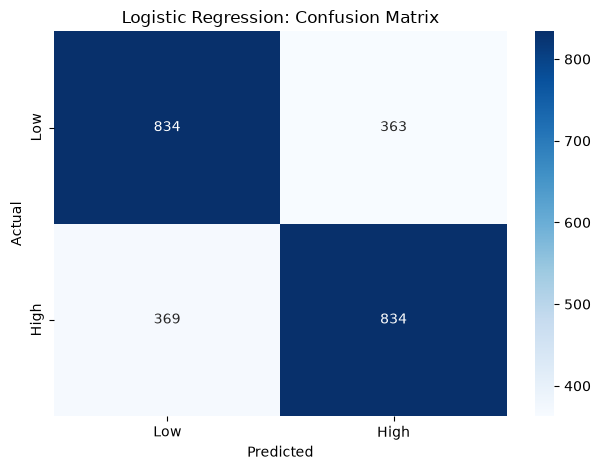

In [2]:
pred = model.predict(X_test)
proba = model.predict_proba(X_test)[:, 1]

metrics = {
    "accuracy": accuracy_score(y_test, pred),
    "precision": precision_score(y_test, pred),
    "recall": recall_score(y_test, pred),
    "f1": f1_score(y_test, pred),
    "roc_auc": roc_auc_score(y_test, proba),
    "cv_accuracy_mean": cross_val_score(model, X, y, cv=5).mean(),
    "cv_accuracy_std": cross_val_score(model, X, y, cv=5).std(),
}
print({k: round(v, 4) for k, v in metrics.items()})
print(classification_report(y_test, pred, target_names=["Low", "High"]))

cm = confusion_matrix(y_test, pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Low", "High"], yticklabels=["Low", "High"])
plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.title("Logistic Regression: Confusion Matrix")
os.makedirs("../outputs/figures", exist_ok=True)
plt.tight_layout(); plt.savefig("../outputs/figures/08_logistic_confusion.png", dpi=150); plt.show()

work_mode_On-site              -0.771
work_mode_Remote               -0.054
log_endorsements               -0.038
skill_count                    -0.010
open_to_work_bin                0.005
update_ord                      0.014
profile_completeness_pct        0.038
connections_ord                 0.064
education_ord                   0.325
in_demand_skill_flag_bin        0.380
uses_generative_ai_tools_bin    0.401
certifications_count            0.441
years_experience                0.732
dtype: float64


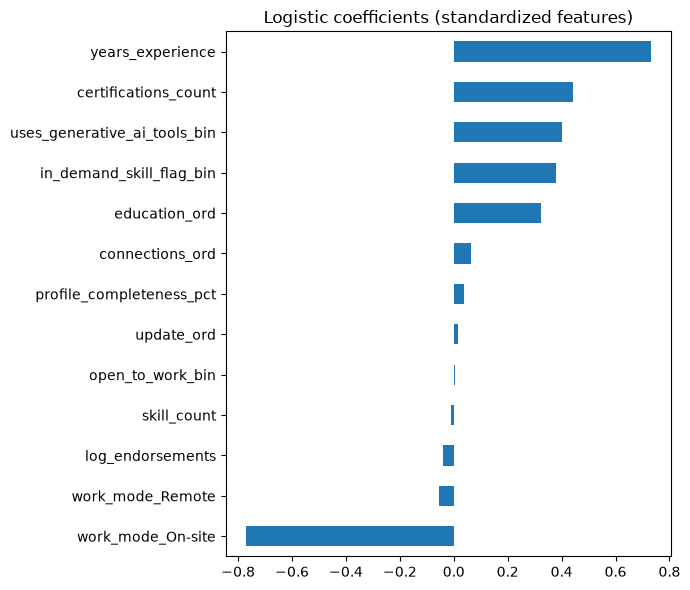

In [3]:
names = num_cols + list(model.named_steps["pre"].named_transformers_["cat"]
                        .get_feature_names_out(cat_cols))
coefs = pd.Series(model.named_steps["clf"].coef_[0], index=names).sort_values()
print(coefs.round(3))
coefs.plot.barh(figsize=(7, 6), title="Logistic coefficients (standardized features)")
plt.tight_layout(); plt.savefig("../outputs/figures/09_logistic_coefficients.png", dpi=150); plt.show()

In [4]:
os.makedirs("../models", exist_ok=True); os.makedirs("../outputs/metrics", exist_ok=True)
joblib.dump(model, "../models/logistic_model.pkl")
json.dump(metrics, open("../outputs/metrics/logistic_metrics.json", "w"), indent=2)